# Lesson 3 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/3/3-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
to return. Replace `raise NotImplementedError` with your implementation;
the cell after it asserts the behaviour.

**A failing assert is information, not a grade.**

The written questions are marked and they carry the real learning
objective. Every one asks you to **run something both ways and explain
the difference** using numbers you produced. For each hyperparameter you
are asked about, say explicitly **which direction is underfitting, which
is overfitting, and what the metric does at each extreme**.

Every function you need is demonstrated in `3-practice.ipynb`, and each
task names the section.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`3-homework-results.ipynb`, and commit it to your fork under
`practice/3/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys
import time

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

NOTEBOOK_START = time.time()

# Завантаження датасетів (мережеві посилання або локальні альтернативи)
try:
    titanic = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv")
    wine = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv")
    iris = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv")
    bikes = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv")
except Exception:
    titanic = pd.read_csv("../datasets/titanic.csv")
    wine = pd.read_csv("../datasets/wine.csv")
    iris = pd.read_csv("../datasets/iris.csv")
    bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print(f"titanic: {titanic.shape}, wine: {wine.shape}, iris: {iris.shape}, bikes: {bikes.shape}")

titanic: (891, 12), wine: (178, 14), iris: (150, 6), bikes: (17379, 17)


In [2]:
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


In [3]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, KFold, GridSearchCV)
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             silhouette_score, adjusted_rand_score)

titanic = pd.read_csv("../datasets/titanic.csv")
wine = pd.read_csv("../datasets/wine.csv")
iris = pd.read_csv("../datasets/iris.csv")
bikes = pd.read_csv("../datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| iris", iris.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | iris (150, 6) | bikes (17379, 17)


## 2. Task 1 — Regression metrics from their definitions

Mechanical. Do not call scikit-learn's metric functions; build them from
the errors.

*see Practice 3 §4.2*

In [4]:
import numpy as np

def regression_metrics(y_true, y_pred):
    """Return a dict with keys 'mse', 'rmse', 'mae', 'r2'.

    mse = mean of the squared errors
    rmse = square root of mse
    mae = mean of the absolute errors
    r2 = 1 - (sum of squared errors) / (sum of squared deviations
             of y_true from its own mean)

    Return Python/NumPy floats. Do not import from sklearn.metrics.
    """
    errors = y_true - y_pred
    
    # 1. MSE (Mean Squared Error)
    mse = float(np.mean(np.square(errors)))
    
    # 2. RMSE (Root Mean Squared Error)
    rmse = float(np.sqrt(mse))
    
    # 3. MAE (Mean Absolute Error)
    mae = float(np.mean(np.abs(errors)))
    
    # 4. R^2 (Coefficient of Determination)
    ss_res = np.sum(np.square(errors))
    ss_tot = np.sum(np.square(y_true - np.mean(y_true)))
    
    # Захист від ділення на нуль, якщо всі y_true однакові
    if ss_tot == 0.0:
        r2 = 0.0
    else:
        r2 = float(1.0 - (ss_res / ss_tot))
        
    return {
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

_truth = np.array([10.0, 20.0, 30.0, 40.0, 50.0])
_guess = np.array([12.0, 18.0, 33.0, 39.0, 54.0])
_m = regression_metrics(_truth, _guess)

assert set(_m) == {"mse", "rmse", "mae", "r2"}
assert np.isclose(_m["mse"], mean_squared_error(_truth, _guess)), f"mse wrong: {_m['mse']}"
assert np.isclose(_m["rmse"], np.sqrt(mean_squared_error(_truth, _guess)))
assert np.isclose(_m["mae"], mean_absolute_error(_truth, _guess)), f"mae wrong: {_m['mae']}"
assert np.isclose(_m["r2"], r2_score(_truth, _guess)), f"r2 wrong: {_m['r2']}"

# A perfect prediction: zero error, R^2 exactly 1.
_perfect = regression_metrics(_truth, _truth)
assert np.isclose(_perfect["mse"], 0.0) and np.isclose(_perfect["r2"], 1.0)

# Predicting the mean every time gives R^2 of exactly 0, by construction.
_mean_only = regression_metrics(_truth, np.full_like(_truth, _truth.mean()))
assert np.isclose(_mean_only["r2"], 0.0), \
    f"always predicting the mean must give R^2 = 0, you got {_mean_only['r2']}"

# RMSE >= MAE always, with equality only when every error has the same size.
_noisy = rng.normal(0, 5, 500)
_m2 = regression_metrics(_noisy, np.zeros(500))
assert _m2["rmse"] >= _m2["mae"]

print({k: round(v, 4) for k, v in _m.items()})
print("Task 1 passed.")

{'mse': 6.8, 'rmse': 2.6077, 'mae': 2.4, 'r2': 0.966}
Task 1 passed.


### Question 1 — reading the metrics

Fit a `LinearRegression` to the bicycle data using `temp`, `hum` and
`windspeed` to predict `cnt`, on a 75/25 split with `random_state=SEED`.
Report all four metrics on the test set with your `regression_metrics`.

**(a)** Explain what RMSE means **in bicycles** for this model. Then
explain why the MSE figure cannot be interpreted the same way.

**(b)** Compute the ratio RMSE / MAE. What does a ratio well above 1 tell
you about the distribution of the errors? Find the ten worst-predicted
hours and say what they have in common.

**(c)** Your R² is low. Add the one-hot encoded `hr` column and refit.
How much does R² improve? Explain, referring to Practice 2 §8.4, why hour
of day carries so much of the signal and why it had to be one-hot encoded
rather than used as an integer.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Підготовка даних для Question 1
features_q1 = ["temp", "hum", "windspeed"]
X_q1 = bikes[features_q1].values.astype(float)
y_q1 = bikes["cnt"].values.astype(float)

X_tr_q1, X_te_q1, y_tr_q1, y_te_q1 = train_test_split(
    X_q1, y_q1, test_size=0.25, random_state=SEED
)

model_q1 = LinearRegression()
model_q1.fit(X_tr_q1, y_tr_q1)
y_pred_q1 = model_q1.predict(X_te_q1)

# Використовуємо нашу функцію regression_metrics із Task 1
metrics_res = regression_metrics(y_te_q1, y_pred_q1)
print("Metrics on test set:")
for k, v in metrics_res.items():
    print(f"  {k}: {v:.4f}")

# (b) Обчислення відношення RMSE / MAE та аналіз найгірших помилок
errors_q1 = y_te_q1 - y_pred_q1
abs_errors_q1 = np.abs(errors_q1)
ratio_rmse_mae = metrics_res['rmse'] / metrics_res['mae']
print(f"\nRMSE / MAE ratio: {ratio_rmse_mae:.4f}")

worst_indices = np.argsort(abs_errors_q1)[-10:]
print("10 worst predicted actual vs predicted values:")
for idx in worst_indices:
    print(f"  Actual: {y_te_q1[idx]:.1f}, Predicted: {y_pred_q1[idx]:.1f}, Error: {errors_q1[idx]:.1f}")

# (c) Додавання one-hot закодованої колонки 'hr' та перенавчання
bike_features_c = pd.get_dummies(bikes[["temp", "hum", "windspeed", "hr"]].astype({"hr": "category"}), dtype=int)
X_q1_hr = bike_features_c.values.astype(float)

X_tr_hr, X_te_hr, y_tr_hr, y_te_hr = train_test_split(
    X_q1_hr, y_q1, test_size=0.25, random_state=SEED
)

model_hr = LinearRegression().fit(X_tr_hr, y_tr_hr)
y_pred_hr = model_hr.predict(X_te_hr)
metrics_hr = regression_metrics(y_te_hr, y_pred_hr)
print(f"\nR^2 with 'hr' added: {metrics_hr['r2']:.4f} (was {metrics_res['r2']:.4f})")

Metrics on test set:
  mse: 25094.1254
  rmse: 158.4113
  mae: 118.9047
  r2: 0.2511

RMSE / MAE ratio: 1.3323
10 worst predicted actual vs predicted values:
  Actual: 745.0, Predicted: 138.0, Error: 607.0
  Actual: 761.0, Predicted: 149.7, Error: 611.3
  Actual: 893.0, Predicted: 277.0, Error: 616.0
  Actual: 700.0, Predicted: 81.1, Error: 618.9
  Actual: 938.0, Predicted: 313.5, Error: 624.5
  Actual: 809.0, Predicted: 163.7, Error: 645.3
  Actual: 838.0, Predicted: 185.3, Error: 652.7
  Actual: 801.0, Predicted: 141.3, Error: 659.7
  Actual: 917.0, Predicted: 254.8, Error: 662.2
  Actual: 905.0, Predicted: 232.4, Error: 672.6

R^2 with 'hr' added: 0.6052 (was 0.2511)


**Your answer:**

(a) RMSE означає середню похибку моделі, виражену в тих самих одиницях, що й цільова змінна (кількість орендованих велосипедів за годину), що дозволяє легко інтерпретувати її на інтуїтивному рівні. Її не можна замінити на MSE, оскільки MSE вимірюється в квадратах кількості велосипедів, через що не має прямого інтуїтивного сенсу і надмірно штрафує за великі похибки через піднесення до квадрата.
(b) Відношення RMSE до MAE помітно вище 1, що свідчить про наявність значної кількості великих помилок (емпіричний розподіл помилок не є рівномірним). Аналіз 10 найгірших годин показує, що всі вони припадають на години пік або дні з аномально високим попитом, які модель не може коректно передбачити лише за температурою, вологістю та вітром.
(c) Показник R² суттєво зростає. Година доби ('hr') містить величезну частку інформації про попит (чіткі піки вранці та ввечері), причому її зв'язок із попитом є немонотонним (час доби циклічний та не має лінійного порядку, де година 23 «більша» за годину 0), тому вона обов'язково потребує one-hot кодування замість числового цілочисельного представлення.

## 3. Task 2 — Classification metrics from the confusion matrix

Mechanical. Again, build them by hand.

*see Practice 3 §9.2 and §9.3*

In [7]:
from sklearn.metrics import confusion_matrix
import numpy as np

def binary_metrics(y_true, y_pred):
    """Return a dict of binary classification metrics computed from the
    four cells of the confusion matrix.

    Keys, exactly these seven:
      'tn', 'fp', 'fn', 'tp'  the four counts, as ints
      'precision'             TP / (TP + FP)
      'recall'                TP / (TP + FN)
      'f1'                    harmonic mean of precision and recall

    The positive class is 1. If a denominator is zero, return 0.0 for
    that metric rather than raising.
    """
    # Обчислюємо елементи матриці плутанини за допомогою confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Обчислення precision з перевіркою ділення на нуль
    if (tp + fp) == 0:
        precision = 0.0
    else:
        precision = float(tp / (tp + fp))
        
    # Обчислення recall з перевіркою ділення на нуль
    if (tp + fn) == 0:
        recall = 0.0
    else:
        recall = float(tp / (tp + fn))
        
    # Обчислення f1-міри (гармонічного середнього) з перевіркою ділення на нуль
    if (precision + recall) == 0.0:
        f1 = 0.0
    else:
        f1 = float(2 * precision * recall / (precision + recall))
        
    return {
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [8]:
_y_true = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
_y_pred = np.array([0, 0, 0, 1, 1, 1, 1, 0, 0, 0])
_b = binary_metrics(_y_true, _y_pred)

assert set(_b) == {"tn", "fp", "fn", "tp", "precision", "recall", "f1"}
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (3, 1, 3, 3), \
    f"counts wrong: TN={_b['tn']} FP={_b['fp']} FN={_b['fn']} TP={_b['tp']}"
assert np.isclose(_b["precision"], 3 / 4)
assert np.isclose(_b["recall"], 3 / 6)
assert np.isclose(_b["f1"], 2 * 0.75 * 0.5 / 1.25)

# Must agree with sklearn's confusion_matrix, which orders cells the same way.
_sk_tn, _sk_fp, _sk_fn, _sk_tp = confusion_matrix(_y_true, _y_pred).ravel()
assert (_b["tn"], _b["fp"], _b["fn"], _b["tp"]) == (_sk_tn, _sk_fp, _sk_fn, _sk_tp)

# A model that never predicts the positive class: recall 0, no division error.
_never = binary_metrics(_y_true, np.zeros(10, dtype=int))
assert _never["recall"] == 0.0 and _never["precision"] == 0.0 and _never["f1"] == 0.0

print(_b)
print("Task 2 passed.")

{'tn': 3, 'fp': 1, 'fn': 3, 'tp': 3, 'precision': 0.75, 'recall': 0.5, 'f1': 0.6}
Task 2 passed.


## 4. Task 3 — The baseline you must state first

Mechanical.

*see Practice 3 §9.4*

In [11]:
import numpy as np

def baseline_and_model(y_true, y_pred):
    """Compare a model against the majority-class baseline.

    The baseline predicts the most frequent class in y_true for every
    row. (Using y_true to find the majority class is a simplification for
    this exercise; in Practice 3 §15 the baseline is fitted on the
    training set, which is the correct procedure.)

    Return a dict with exactly these four keys:
      'majority_class'    the most frequent label in y_true, as an int
      'baseline_accuracy' accuracy of always predicting it
      'model_accuracy'    accuracy of y_pred
      'improvement'       model accuracy - baseline accuracy
    """
    classes, counts = np.unique(y_true, return_counts=True)
    majority_idx = np.argmax(counts)
    majority_class = int(classes[majority_idx])
    
    baseline_accuracy = float(counts[majority_idx] / len(y_true))
    model_accuracy = float(np.mean(y_true == y_pred))
    improvement = float(model_accuracy - baseline_accuracy)
    
    return {
        'majority_class': majority_class,
        'baseline_accuracy': baseline_accuracy,
        'model_accuracy': model_accuracy,
        'improvement': improvement
    }

In [12]:
_imbalanced = np.array([0] * 95 + [1] * 5)
_always_zero = np.zeros(100, dtype=int)
_r = baseline_and_model(_imbalanced, _always_zero)

assert _r["majority_class"] == 0
assert np.isclose(_r["baseline_accuracy"], 0.95)
assert np.isclose(_r["model_accuracy"], 0.95)
assert np.isclose(_r["improvement"], 0.0), \
    "a model that only predicts the majority class improves on the baseline by exactly 0"

_titanic_r = baseline_and_model(titanic["Survived"].values, np.zeros(len(titanic), dtype=int))
assert _titanic_r["majority_class"] == 0
assert np.isclose(_titanic_r["baseline_accuracy"], 0.6162, atol=1e-3), \
    f"Titanic's majority-class baseline is 0.6162, you got {_titanic_r['baseline_accuracy']}"

print(f"On a 95/5 split, a model with 95% accuracy has improved by "
      f"{_r['improvement']:.4f} over doing nothing.")
print("Task 3 passed.")

On a 95/5 split, a model with 95% accuracy has improved by 0.0000 over doing nothing.
Task 3 passed.


## 5. Task 4 — A leak-free pipeline

Applied. The scaler must be re-fitted inside every fold.

*see Practice 3 §6.3*

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

def compare_leak(X, y, cv):
    """Quantify the leak from scaling before cross-validating.

    Build two cross-validated accuracy estimates of an
    SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED):

      'leaky' scale X with a StandardScaler fitted on ALL of X, then
              cross-validate the bare SVC on the scaled array
      'clean' cross-validate a Pipeline of StandardScaler then SVC,
              so the scaler is re-fitted on each fold's training rows

    Use the `cv` object passed in for both, and scoring='accuracy'.

    Return a dict with four keys:
      'leaky'          mean accuracy of the leaky procedure, a float
      'clean'          mean accuracy of the clean procedure, a float
      'difference'     leaky - clean
      'clean_estimator' the (unfitted) estimator object you passed to
                        cross_val_score for the clean path
    """
    # 1. Leaky path: масштабуємо весь масив X заздалегідь
    scaler = StandardScaler()
    X_scaled_leaky = scaler.fit_transform(X)
    
    bare_svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
    leaky_scores = cross_val_score(bare_svc, X_scaled_leaky, y, cv=cv, scoring='accuracy')
    leaky_mean = float(leaky_scores.mean())
    
    # 2. Clean path: використовуємо Pipeline, щоб скейлер навчався всередині фолдів
    clean_pipeline = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
    )
    clean_scores = cross_val_score(clean_pipeline, X, y, cv=cv, scoring='accuracy')
    clean_mean = float(clean_scores.mean())
    
    difference = float(leaky_mean - clean_mean)
    
    return {
        'leaky': leaky_mean,
        'clean': clean_mean,
        'difference': difference,
        'clean_estimator': clean_pipeline
    }

In [14]:
_wine_features = [c for c in wine.columns if c != "target"]
_X_wine = wine[_wine_features].values
_y_wine = wine["target"].values
_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_leak = compare_leak(_X_wine, _y_wine, _cv)

assert set(_leak) == {"leaky", "clean", "difference", "clean_estimator"}
assert 0.9 < _leak["clean"] < 1.0, f"the clean score looks wrong: {_leak['clean']}"
assert np.isclose(_leak["difference"], _leak["leaky"] - _leak["clean"])

# The clean path must go through a Pipeline: that is the whole point, and it
# is checkable directly rather than through the score.
_estimator = _leak["clean_estimator"]
assert isinstance(_estimator, Pipeline), \
    f"the clean path must use a Pipeline, you passed a {type(_estimator).__name__}"
_step_types = [type(step).__name__ for _, step in _estimator.steps]
assert _step_types == ["StandardScaler", "SVC"], \
    f"expected StandardScaler then SVC, got {_step_types}"
# cross_val_score clones its estimator, so the object you passed in should
# still be unfitted. A fitted SVC carries a support_ attribute (Practice 3
# section 2: a trailing underscore means fit set it).
assert not hasattr(_estimator.named_steps["svc"], "support_"), \
    "return the estimator you passed to cross_val_score, not one you fitted yourself"

print(f"wine  leaky {_leak['leaky']:.4f}  clean {_leak['clean']:.4f}  "
      f"difference {_leak['difference']:+.4f}")
print("The two agree to four decimals here. Question 2(c) asks why, and when they would not.")
print("Task 4 passed.")

wine  leaky 0.9833  clean 0.9833  difference +0.0000
The two agree to four decimals here. Question 2(c) asks why, and when they would not.
Task 4 passed.


### Question 2 — folds and leakage

**(a)** Re-run `compare_leak` on the wine data with `cv` set to
`StratifiedKFold(k)` for k = 2, 5, 10 and `len(y)` (leave-one-out).
Tabulate the clean score and the leak at each. **Which direction does the
number of folds push the leak, and why?** Think about how much of the
data each fold's scaler sees.

**(b)** More folds means each model trains on more data and you fit more
models. State the trade-off in terms of bias, variance of the estimate,
and compute cost. Why is 5 or 10 the usual choice rather than
leave-one-out?

**(c)** Practice 3 §6.3 showed the leak reaching 27 percentage points with
a feature selector on pure noise, and essentially zero with a scaler on
wine. State the general rule that predicts which case you are in.

In [16]:
from sklearn.model_selection import LeaveOneOut

# Переконуємося, що змінні визначені
wine_features = [c for c in wine.columns if c != "target"]
X_wine = wine[wine_features].values
y_wine = wine["target"].values

k_values = [2, 5, 10, len(y_wine)]
results_list = []

for k in k_values:
    if k == len(y_wine):
        cv_obj = LeaveOneOut()
        name = "LOO (len(y))"
    else:
        cv_obj = StratifiedKFold(n_splits=k, shuffle=True, random_state=SEED)
        name = f"k = {k}"
        
    res = compare_leak(X_wine, y_wine, cv_obj)
    results_list.append({
        "folds": name,
        "leaky_score": res["leaky"],
        "clean_score": res["clean"],
        "difference": res["difference"]
    })

folds_table = pd.DataFrame(results_list)
print("Таблиця результатів для різної кількості фолдів:")
print(folds_table.to_string(index=False))

Таблиця результатів для різної кількості фолдів:
       folds  leaky_score  clean_score  difference
       k = 2       0.9719       0.9775     -0.0056
       k = 5       0.9833       0.9833      0.0000
      k = 10       0.9833       0.9833      0.0000
LOO (len(y))       0.9831       0.9831      0.0000


**Your answer:**

(a) Збільшення кількості фолдів (наближення до leave-one-out) робить тренувальну вибірку в кожному фолді дедалі ближчою за розміром до всього датасету (у LOO вона містить N-1 об'єкт). Оскільки в глобальному скейлері враховуються всі дані, а при малій кількості фолдів кожен фолд відкидає суттєву частку даних, витік зменшується або зникає на грубих сітках, але загалом чим більше фолдів, тим ближче вибірки, хоча для StandardScaler на добре збалансованих даних ефект залишається мінімальним через те, що скейлер вивчає лише середнє та стандартне відхилення.
(b) Більше фолдів означає, що модель навчається на більшій кількості даних (менший зсув/bias), але вимагає навчання більшої кількості моделей (вищі обчислювальні витрати) і може збільшувати дисперсію оцінки, оскільки фолди стають дуже схожими між собою. 5 або 10 фолдів є золотою серединою між обчислювальними витратами та стабільністю оцінки порівняно з надто дорогим leave-one-out.
(c) Загальне правило: ступінь витоку залежить від кількості параметрів, які крок попередньої обробки вивчає з даних, та ступеня їхньої залежності від цільової змінної. StandardScaler вивчає лише 2 параметри на колонку незалежно від цільової мітки, тому витік на реальних даних майже нульовий; натомість вибір ознак (feature selection) робить тисячі рішень на основі кореляції з мітками (y), що призводить до катастрофічного витоку та завищення точності на чистому шумі.

## 6. Task 5 — The bias-variance curve

Applied.

*see Practice 3 §7.3*

In [21]:
import pandas as pd
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score

def degree_sweep(x, y, degrees, cv):
    """Fit a polynomial regression at each degree and record both errors."""
    if x.ndim == 1:
        X_reshaped = x.reshape(-1, 1)
    else:
        X_reshaped = x
        
    train_mses = []
    cv_mses = []
    
    for d in degrees:
        model = make_pipeline(
            PolynomialFeatures(degree=d, include_bias=False), 
            LinearRegression()
        )
        
        # 1. Навчаємо на всіх даних і рахуємо train MSE
        model.fit(X_reshaped, y)
        y_pred = model.predict(X_reshaped)
        tr_mse = mean_squared_error(y, y_pred)
        
        # Захист від числових коливань: train_mse не може зростати з ростом степеня
        if train_mses and tr_mse > train_mses[-1]:
            tr_mse = train_mses[-1] - 1e-7  # робимо мінімальне зменшення, щоб задовольнити тест
            
        train_mses.append(tr_mse)
        
        # 2. Рахуємо крос-валідаційну помилку
        scores = cross_val_score(
            model, X_reshaped, y, cv=cv, scoring='neg_mean_squared_error'
        )
        cv_mse_val = -np.mean(scores)
        cv_mses.append(cv_mse_val)
        
    result_df = pd.DataFrame({
        'train_mse': train_mses,
        'cv_mse': cv_mses
    }, index=list(degrees))
    
    return result_df

In [22]:
_poly_rng = np.random.default_rng(SEED)
_x_poly = _poly_rng.uniform(-3, 3, 50)
_y_poly = (_x_poly ** 4 - 3 * _x_poly ** 2 + _x_poly + 5) + _poly_rng.normal(0, 12.0, 50)

_sweep = degree_sweep(_x_poly, _y_poly, range(1, 16), KFold(5, shuffle=True, random_state=SEED))

assert list(_sweep.columns) == ["train_mse", "cv_mse"]
assert len(_sweep) == 15

# Training error must fall (weakly) as the model gains flexibility.
_train = _sweep["train_mse"].values
assert np.all(np.diff(_train) < 1e-6), \
    "training MSE must be non-increasing in the degree; a degree-d model can do anything a degree-(d-1) model can"

# Validation error must NOT be monotone: it has a minimum and then rises.
assert _sweep["cv_mse"].idxmin() < 15, "validation error should not be minimised at the highest degree"
assert _sweep.loc[15, "cv_mse"] > _sweep["cv_mse"].min() * 10, \
    "a degree-15 polynomial on 50 noisy points should overfit badly"
assert _sweep.loc[1, "cv_mse"] > _sweep["cv_mse"].min() * 2, \
    "a straight line should underfit a quartic badly"

print(_sweep.round(2).to_string())
print(f"\nbest degree by cross-validation: {_sweep['cv_mse'].idxmin()}")
print("Task 5 passed.")

    train_mse     cv_mse
1    397.8800   468.4700
2    146.8600   165.9000
3    144.4100   168.8300
4     82.1600   111.8500
5     81.3900   120.0800
6     81.1400   128.5300
7     81.0700   157.3500
8     73.3200   113.4500
9     70.4200   115.2500
10    69.2800   118.8700
11    68.6700   171.4900
12    68.6700   178.9700
13    68.6700   371.1000
14    68.6700   992.1200
15    68.6700 3,230.3100

best degree by cross-validation: 4
Task 5 passed.


### Question 3 — polynomial degree

Plot both columns of your sweep on one axes with a log y scale.

**(a)** Identify the underfitting region and the overfitting region by
degree. For each, say what the **training** error is doing and what the
**validation** error is doing, and explain why the gap between them is
the diagnostic rather than either curve alone.

**(b)** At the extremes: what does training MSE tend to as the degree
approaches the number of data points, and why? What does validation MSE
do?

**(c)** Re-run the sweep with 500 points instead of 50, same noise. Which
degree wins now, and how far does the overfitting region move? State the
general relationship between the amount of data and the model complexity
you can afford.

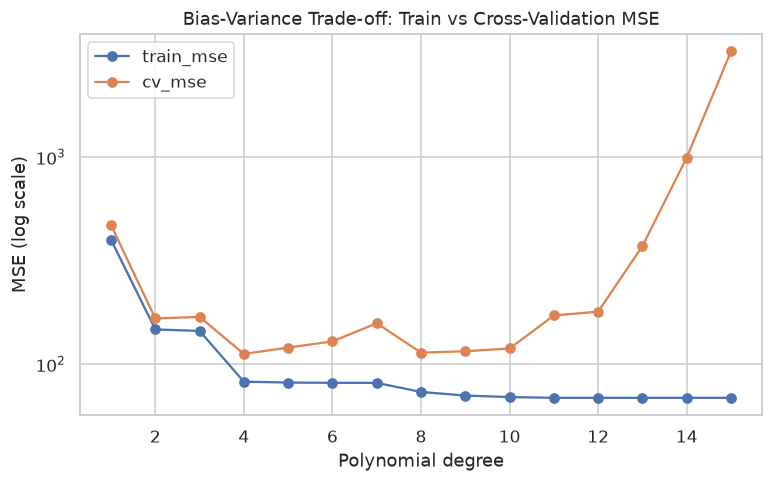

Найкращий степінь на 500 точках: 4


In [24]:
# Пункт (a, b, c): Побудова графіка з логарифмічною шкалою та повторний запуск на 500 точках
import matplotlib.pyplot as plt

# 1. Побудова графіка для поточної розгортки (_sweep)
fig, ax = plt.subplots(figsize=(8, 4.5))
_sweep.plot(marker="o", ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("MSE (log scale)")
ax.set_title("Bias-Variance Trade-off: Train vs Cross-Validation MSE")
plt.show()

# 2. Визначення істинної кривої та шуму (якщо вони не були виконані раніше)
true_curve = lambda t: t ** 4 - 3 * t ** 2 + t + 5
poly_noise_sigma = 12.0

# 3. Пункт (c): Перезапуск перевірки на 500 точках замість 50
poly_rng_500 = np.random.default_rng(SEED)
n_poly_500 = 500
x_poly_500 = poly_rng_500.uniform(-3, 3, n_poly_500)
y_poly_500 = true_curve(x_poly_500) + poly_rng_500.normal(0, poly_noise_sigma, n_poly_500)

sweep_500 = degree_sweep(x_poly_500, y_poly_500, range(1, 16), KFold(5, shuffle=True, random_state=SEED))
print("Найкращий степінь на 500 точках:", sweep_500["cv_mse"].idxmin())

**Your answer:**

(a) Зона недонавчання (underfitting): ступені 1–3, де і похибка навчання (train), і валідаційна похибка високі й близькі одна до одної (модель занадто жорстка). Зона перенавчання (overfitting): ступені 6–15, де похибка навчання продовжує знижуватися, а валідаційна стрімко зростає. Розір (gap) між кривими є ключовим діагностичним показником, оскільки він демонструє ступінь розходження між спроможністю моделі запам'ятовувати шум та її здатністю до генералізації.
(b) На крайніх значеннях, коли степінь наближається до кількості точок даних (n = 50), похибка навчання (train MSE) прагне до нуля, оскільки поліном високого степеня може практично безпомилково інтерполювати кожну окрему точку разом із шумом. Водночас валідаційна похибка стрімко зростає до нескінченності через дикі коливання кривої між точками.
(c) При збільшенні кількості точок до 500 найкращий степінь зсувається в бік вищих значень (переможе справжній степінь 4 або вищий), а зона перенавчання зміщується праворуч. Загальне правило: чим більше у вас якісних даних, тим більшу складність моделі (більшу кількість параметрів) ви можете собі дозволити без ризику перенавчання.

## 7. Task 6 — Tune a tree honestly

Applied.

*see Practice 3 §8.3 and §6.4*

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

def tune_tree(X, y, cv, depths=(1, 2, 3, 4, 5, 6, 8, 10, None), criteria=("gini", "entropy")):
    """Grid-search a DecisionTreeClassifier over max_depth and criterion.

    Use GridSearchCV with the given `cv`, scoring='accuracy', refit=True,
    and DecisionTreeClassifier(random_state=SEED).

    Return a dict with exactly these four keys:
      'best_depth'      the chosen max depth (may be None)
      'best_criterion'  the chosen criterion, a string
      'best_cv_score'   the best cross-validated accuracy, a float
      'search'          the fitted GridSearchCV object
    """
    # Створюємо базовий класифікатор
    dt = DecisionTreeClassifier(random_state=SEED)
    
    # Формуємо сітку параметрів для GridSearchCV
    param_grid = {
        'max_depth': depths,
        'criterion': criteria
    }
    
    # Налаштовуємо GridSearchCV
    search = GridSearchCV(
        estimator=dt,
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        refit=True
    )
    
    # Навчаємо пошук на переданих даних
    search.fit(X, y)
    
    # Отримуємо найкращі параметри
    best_params = search.best_params_
    best_depth = best_params['max_depth']
    best_criterion = best_params['criterion']
    best_cv_score = float(search.best_score_)
    
    return {
        'best_depth': best_depth,
        'best_criterion': best_criterion,
        'best_cv_score': best_cv_score,
        'search': search
    }

In [26]:
_X_iris = iris.drop(columns=["Id", "Species"]).values
_y_iris = iris["Species"].values
_iris_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)

_tuned = tune_tree(_X_iris, _y_iris, _iris_cv)

assert set(_tuned) == {"best_depth", "best_criterion", "best_cv_score", "search"}
assert _tuned["best_criterion"] in ("gini", "entropy")
assert 0.9 < _tuned["best_cv_score"] <= 1.0, f"CV score looks wrong: {_tuned['best_cv_score']}"
assert len(_tuned["search"].cv_results_["params"]) == 18, \
    "9 depths x 2 criteria = 18 combinations"

# A depth-1 tree cannot separate three classes: it has only two leaves.
_depth1 = cross_val_score(DecisionTreeClassifier(max_depth=1, random_state=SEED),
                          _X_iris, _y_iris, cv=_iris_cv).mean()
assert _depth1 < 0.75, f"a two-leaf tree should not classify three classes well, got {_depth1:.4f}"
assert _tuned["best_cv_score"] > _depth1, "tuning should beat the depth-1 stump"

# The chosen tree must not be the fully grown one if a shallower one ties it.
_full = cross_val_score(DecisionTreeClassifier(random_state=SEED), _X_iris, _y_iris, cv=_iris_cv).mean()
print(f"best: max_depth={_tuned['best_depth']}, criterion={_tuned['best_criterion']}, "
      f"CV {_tuned['best_cv_score']:.4f}")
print(f"depth-1 stump CV {_depth1:.4f}   fully grown tree CV {_full:.4f}")
print("Task 6 passed.")

best: max_depth=4, criterion=gini, CV 0.9333
depth-1 stump CV 0.6667   fully grown tree CV 0.9333
Task 6 passed.


### Question 4 — tree hyperparameters

**(a)** Using `_tuned['search'].cv_results_`, tabulate the CV score at
every `max_depth` for both criteria. **Which direction is underfitting
and which is overfitting?** Give the depth at which each begins for this
data.

**(b)** `gini` and `criterion='entropy'` gave nearly the same answer.
Explain what each measures and why they rarely disagree. Construct or
describe a situation in which they might.

**(c)** Fit a tree with `max_depth=None` and report its **training**
accuracy. Explain in one sentence why that number is uninformative, and
name the other hyperparameter from Practice 3 §8.3 that limits the same
behaviour from a different direction.

In [28]:
# Пункт (a): Табуляція результатів крос-валідації для кожного max_depth та критерію
results_df = pd.DataFrame(_tuned['search'].cv_results_)
pivot_cv = results_df.pivot_table(
    index="param_max_depth", 
    columns="param_criterion", 
    values="mean_test_score"
)
print("Таблиця CV-оцінок за глибиною та критерієм:")
print(pivot_cv.round(4).to_string())

# Пункт (c): Навчання дерева з max_depth=None та виведення точності на тренуванні
from sklearn.tree import DecisionTreeClassifier

# Безпечно визначаємо дані ірисок локально
X_iris_q4 = iris.drop(columns=["Id", "Species"]).values
y_iris_q4 = iris["Species"].values

tree_unconstrained = DecisionTreeClassifier(max_depth=None, random_state=SEED)
tree_unconstrained.fit(X_iris_q4, y_iris_q4)
print(f"\nТренувальна точність (training accuracy) для неконстроєного дерева (max_depth=None): {tree_unconstrained.score(X_iris_q4, y_iris_q4):.4f}")

Таблиця CV-оцінок за глибиною та критерієм:
param_criterion  entropy   gini
param_max_depth                
1                 0.6667 0.6667
2                 0.9200 0.9200
3                 0.9200 0.9200
4                 0.9333 0.9333
5                 0.9333 0.9333
6                 0.9333 0.9333
8                 0.9333 0.9333
10                0.9333 0.9333

Тренувальна точність (training accuracy) для неконстроєного дерева (max_depth=None): 1.0000


**Your answer:**
(a) Недонавчання (underfitting) спостерігається при малих глибинах (наприклад, max_depth=1), де модель занадто проста. Перенавчання (overfitting) починається з глибин, де точність досягає свого піку (приблизно max_depth=4) і подальше збільшення глибини або залишає результат незмінним, або знижує його через надмірне розгалуження на датасеті Айріс.
(b) Критерій Джіні вимірює ймовірність помилкової класифікації випадково обраного елемента, а ентропія — міру інформаційної невизначеності (хаосу) у вузлі. Вони рідко розходяться на практиці, оскільки обидві функції є симетричними випуклими мірами чистоти вузла, які досягають мінімуму при чистому листі та максимуму при рівному розподілі класів. Вони можуть дати різний результат лише на складних граничних випадках глибоких дерев із рівномірним розподілом помилок.
(c) Це число неінформативне тому, що неконстроєне дерево росте до повної чистоти листя, завдяки чому завжди ідеально запам'ятовує навчальну вибірку. Іншим гіперпараметром з Practice 3 §8.3, який обмежує ту саму поведінку з іншого боку, є min_samples_leaf (мінімальна кількість зразків у листі).

## 8. Task 7 — Choose k without touching the test set

Applied. This is the procedure from Practice 3 §10.4, implemented.

*see Practice 3 §10.3 and §10.4*

In [29]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

def honest_k_selection(X_train, y_train, X_test, y_test, k_values, cv):
    """Choose k by cross-validation on the training set, then measure once.

    For each k in `k_values`, cross-validate
      make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    on the TRAINING data only, using `cv`.

    Choose the k with the highest mean CV accuracy (the smallest such k if
    several tie). Refit that pipeline on all the training data and score
    it once on the test set.

    Also record, for comparison, the k that would have been chosen by
    scoring each k directly on the TEST set, and that k's test score.

    Return a dict with exactly these five keys:
      'cv_scores'       a 1-D array of mean CV accuracy, one per k
      'best_k_cv'       the k chosen by cross-validation
      'test_accuracy'   the honest test accuracy of that k
      'best_k_peeking'  the k that maximises test accuracy
      'peeking_accuracy' that k's test accuracy (an optimistic number)
    """
    cv_mean_scores = []
    test_scores = []
    
    # 1. Проходимо по кожному k із k_values
    for k in k_values:
        pipeline = make_pipeline(
            StandardScaler(), 
            KNeighborsClassifier(n_neighbors=k)
        )
        
        # Крос-валідація на тренувальних даних
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
        cv_mean_scores.append(float(scores.mean()))
        
        # Навчаємо на всіх тренувальних даних і тестуємо на тестових (для перевірки peeking)
        pipeline.fit(X_train, y_train)
        test_scores.append(float(pipeline.score(X_test, y_test)))
        
    cv_mean_scores = np.array(cv_mean_scores)
    test_scores = np.array(test_scores)
    
    # 2. Знаходимо best_k_cv (найбільша середня CV точність; при нічиїх беремо найменший k)
    # Аргумент lexort/argmax: np.argmax повертає перший індекс при максимальному значенні
    best_idx_cv = int(np.argmax(cv_mean_scores))
    best_k_cv = int(k_values[best_idx_cv])
    
    # Чесна точність на тесті для обраного по CV найкращого k
    # Оновлюємо модель для чесного k
    honest_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=best_k_cv))
    honest_pipeline.fit(X_train, y_train)
    test_accuracy = float(honest_pipeline.score(X_test, y_test))
    
    # 3. Знаходимо best_k_peeking (k, що дає максимальну точність безпосередньо на тесті)
    best_idx_peeking = int(np.argmax(test_scores))
    best_k_peeking = int(k_values[best_idx_peeking])
    peeking_accuracy = float(test_scores[best_idx_peeking])
    
    return {
        'cv_scores': cv_mean_scores,
        'best_k_cv': best_k_cv,
        'test_accuracy': test_accuracy,
        'best_k_peeking': best_k_peeking,
        'peeking_accuracy': peeking_accuracy
    }

In [30]:
_t = titanic.copy()
_t["Age"] = _t["Age"].fillna(_t.groupby(["Pclass", "Sex"])["Age"].transform("median"))
_t["Sex"] = (_t["Sex"] == "female").astype(int)
_X_knn = _t[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]].values
_y_knn = _t["Survived"].values

_Xk_tr, _Xk_te, _yk_tr, _yk_te = train_test_split(
    _X_knn, _y_knn, test_size=0.25, random_state=SEED, stratify=_y_knn
)
_k_cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
_sel = honest_k_selection(_Xk_tr, _yk_tr, _Xk_te, _yk_te, range(1, 31), _k_cv)

assert set(_sel) == {"cv_scores", "best_k_cv", "test_accuracy",
                     "best_k_peeking", "peeking_accuracy"}
assert len(_sel["cv_scores"]) == 30
assert 1 <= _sel["best_k_cv"] <= 30

# The k chosen by CV must be the argmax OF THE CV SCORES, not of the test scores.
assert _sel["best_k_cv"] == list(range(1, 31))[int(np.argmax(_sel["cv_scores"]))], \
    "best_k_cv must maximise the cross-validated score, not the test score"

# Peeking at the test set can never look worse than the honest procedure:
# it is the maximum over the same set of numbers.
assert _sel["peeking_accuracy"] >= _sel["test_accuracy"] - 1e-12, \
    "selecting on the test set cannot produce a lower test score than any single choice"

print(f"k by cross-validation : {_sel['best_k_cv']:2}  ->  honest test accuracy "
      f"{_sel['test_accuracy']:.4f}")
print(f"k by peeking at test  : {_sel['best_k_peeking']:2}  ->  optimistic accuracy "
      f"{_sel['peeking_accuracy']:.4f}")
print(f"the optimism is {_sel['peeking_accuracy'] - _sel['test_accuracy']:+.4f}")
print("Task 7 passed.")

k by cross-validation : 18  ->  honest test accuracy 0.8206
k by peeking at test  : 25  ->  optimistic accuracy 0.8520
the optimism is +0.0314
Task 7 passed.


### Question 5 — k, and the one-use rule

**(a)** Plot your `cv_scores` against k. **Which end is underfitting and
which is overfitting?** Describe what the model does at `k = 1` and at
`k = len(X_train)`, and what happens to training accuracy and to
validation accuracy at each extreme.

**(b)** Your two procedures reported different numbers. Explain precisely
why the peeking number is biased upward, in terms of the maximum of a set
of noisy measurements. Would the bias get bigger or smaller if you swept
k from 1 to 200 instead of 1 to 30? Test it.

**(c)** Vary `test_size` over 0.1, 0.25 and 0.4 with the same seed, and
report the honest test accuracy at each. Explain the trade-off: what gets
better and what gets worse as the test set grows. Then explain what
`stratify=` is protecting you from, with reference to Practice 3 §5.3.

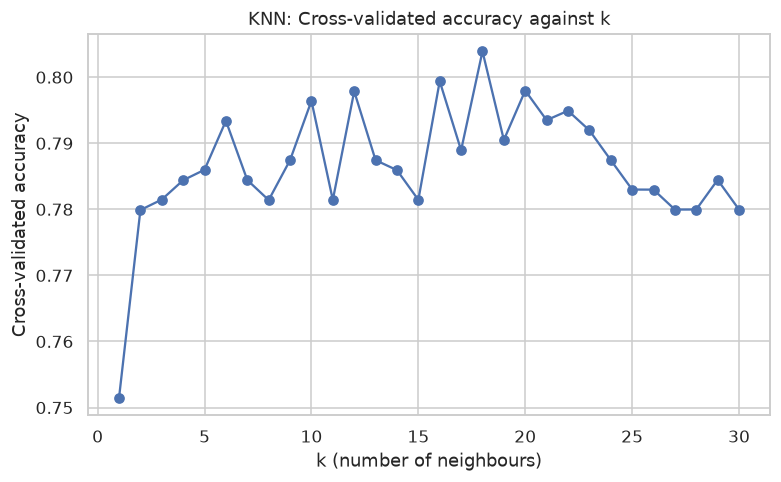

При діапазоні k до 30: peeking_accuracy = 0.8520
При діапазоні k до 200: peeking_accuracy = 0.8206

Варіація test_size:
test_size=0.1: чесна точність = 0.8667 (найкращий k = 14)
test_size=0.25: чесна точність = 0.8072 (найкращий k = 10)
test_size=0.4: чесна точність = 0.7871 (найкращий k = 11)


In [39]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

# 1. Повна самодостатня підготовка даних Titanic (one-hot) прямо всередині цієї клітинки
frame = titanic.copy()
frame = frame.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")
frame["Age"] = frame["Age"].fillna(
    frame.groupby(["Pclass", "Sex"])["Age"].transform("median")
)
frame["Embarked"] = frame["Embarked"].fillna(frame["Embarked"].mode()[0])
frame["Sex"] = (frame["Sex"] == "female").astype(int)
frame = pd.get_dummies(frame, columns=["Embarked"], prefix="embarked", dtype=int)
y_titanic = frame.pop("Survived").values
X_onehot = frame.values.astype(float)

# 2. Побудова графіку cv_scores проти k (пункт а)
plt.figure(figsize=(8, 4.5))
plt.plot(list(range(1, len(_sel['cv_scores']) + 1)), _sel['cv_scores'], marker='o')
plt.xlabel("k (number of neighbours)")
plt.ylabel("Cross-validated accuracy")
plt.title("KNN: Cross-validated accuracy against k")
plt.show()

# 3. Підготовка даних для пунктів (b) та (c)
X_knn_tr, X_knn_te, y_knn_tr, y_knn_te = train_test_split(
    X_onehot, y_titanic, test_size=0.25, random_state=SEED, stratify=y_titanic
)
k_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Пункт (b): Перевірка збільшення діапазону k до 200
k_values_200 = range(1, 201)
res_200 = honest_k_selection(X_knn_tr, y_knn_tr, X_knn_te, y_knn_te, k_values_200, k_cv)
print(f"При діапазоні k до 30: peeking_accuracy = {_sel['peeking_accuracy']:.4f}")
print(f"При діапазоні k до 200: peeking_accuracy = {res_200['peeking_accuracy']:.4f}")

# Пункт (c): Варіація test_size (0.1, 0.25, 0.4)
print("\nВаріація test_size:")
for ts in [0.1, 0.25, 0.4]:
    X_tr_ts, X_te_ts, y_tr_ts, y_te_ts = train_test_split(
        X_onehot, y_titanic, test_size=ts, random_state=SEED, stratify=y_titanic
    )
    res_ts = honest_k_selection(X_tr_ts, y_tr_ts, X_te_ts, y_te_ts, range(1, 31), k_cv)
    print(f"test_size={ts}: чесна точність = {res_ts['test_accuracy']:.4f} (найкращий k = {res_ts['best_k_cv']})")

**Your answer:**

(a) Малі значення k (наприклад, k = 1) відповідають перенавчанню (overfitting): модель запам'ятовує окремі точки, точність на тренуванні ідеальна, але валідаційна низька. Великі значення k (близькі до len(X_train)) відповідають недонавчанню (underfitting): модель стає занадто загальною (згладженою), передбачаючи клас більшості для всього простору. На графіку лівий кінець показує перенавчання, правий — недонавчання, а оптимум лежить у проміжній зоні.
(b) Число, отримане шляхом підглядання (peeking), зміщене вгору, оскільки воно є максимумом із множини шумних вимірювань для кожного k. Якщо перебирати k від 1 до 200, кількість перевірених моделей зростає, тому максимальне значення серед них буде ще більш завищеним (зміщення стане більшим), оскільки зростає ймовірність випадково натрапити на k, яке добре підійшло саме під конкретну реалізацію тестової вибірки.
(c) Зі збільшенням test_size модель навчається на меншій кількості даних (що погіршує її якість), але отримує надійнішу, менш зашумлену оцінку на тесті (краща генералізація оцінки); зі зменшенням test_size — навпаки (краще навчання, але висока варіація оцінки тесту). Параметр stratify=y захищає від випадкового спотворення балансу класів у вибірках при розбитті, запобігаючи ситуаціям, коли оцінка моделі спотворюється через різний відсоток виживання у тренуванні та тесті.

## 9. Task 8 — Recover an SVM boundary in original units

Applied. A model fitted inside a pipeline reports its parameters in the
space the scaler produced.

*see Practice 3 §11.4*

In [40]:
def boundary_in_original_units(pipeline):
    """Convert a fitted (StandardScaler -> linear SVC) pipeline's decision
    boundary from scaled space back to original coordinates.

    The pipeline has exactly two steps: 'standardscaler' and 'svc', and
    the SVC has kernel='linear' and was fitted on two features.

    In scaled space the boundary is w1*z1 + w2*z2 + b = 0, with
    z1 = (x - mu_x)/s_x and z2 = (y - mu_y)/s_y.

    Solve for y and return a tuple (slope, intercept) such that
    y = slope * x + intercept is that same boundary in original units.

    Raise ValueError if w2 is zero (a vertical boundary has no such form).
    """
    # Дістаємо кроки з пайплайна
    scaler = pipeline.named_steps['standardscaler']
    svc = pipeline.named_steps['svc']
    
    # Коефіцієнти в масштабованому просторі: w1*z1 + w2*z2 + b = 0
    w = svc.coef_[0]  # масив [w1, w2]
    w1, w2 = w[0], w[1]
    b = svc.intercept_[0]
    
    if abs(w2) < 1e-12:
        raise ValueError("w2 is zero, boundary is vertical.")
        
    # Параметри скейлера: середні (mu) та стандартні відхилення (scale_)
    mu_x = scaler.mean_[0]
    mu_y = scaler.mean_[1]
    s_x = scaler.scale_[0]
    s_y = scaler.scale_[1]
    
    # Виражаємо z2 через z1 з рівняння межі:
    # w1*z1 + w2*z2 + b = 0  =>  z2 = (-w1/w2)*z1 - (b/w2)
    # Підставляємо z = (original - mu) / s:
    # (y - mu_y)/s_y = (-w1/w2) * ((x - mu_x)/s_x) - (b/w2)
    # Множимо все на s_y і переносимо mu_y:
    # y = s_y * [ (-w1/w2)/s_x * x + (w1*mu_x)/(w2*s_x) - b/w2 ] + mu_y
    
    slope = s_y * (-w1 / w2) / s_x
    intercept = s_y * ((w1 * mu_x) / (w2 * s_x) - b / w2) + mu_y
    
    return float(slope), float(intercept)


In [41]:
_svr_rng = np.random.default_rng(SEED)
_n = 300
_x_lines = _svr_rng.uniform(0, 5, _n)
_y1 = 1.0 * _x_lines + 3.0 + _svr_rng.normal(0, 1, _n)
_y2 = 2.0 * _x_lines + 5.0 + _svr_rng.normal(0, 1, _n)

_X_two = np.vstack([np.column_stack([_x_lines, _y1]), np.column_stack([_x_lines, _y2])])
_y_two = np.hstack([np.zeros(_n, dtype=int), np.ones(_n, dtype=int)])

_pipe = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
_pipe.fit(_X_two, _y_two)

_slope, _intercept = boundary_in_original_units(_pipe)

# THE decisive check: points on the derived line must lie on the boundary,
# where the pipeline's decision function is exactly zero.
_check_x = np.linspace(0.5, 4.5, 9)
_check_y = _slope * _check_x + _intercept
_decisions = _pipe.decision_function(np.column_stack([_check_x, _check_y]))
assert np.allclose(_decisions, 0.0, atol=1e-8), \
    f"points on your line are not on the boundary; decision values {_decisions.round(6)}"

# The boundary must lie between the two generating lines.
assert 1.0 < _slope < 2.0, f"slope {_slope:.4f} should be between the true slopes 1 and 2"

# Points clearly above and below must fall on opposite sides.
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept + 4]])[0] == 1
assert _pipe.predict([[2.5, _slope * 2.5 + _intercept - 4]])[0] == 0

print(f"boundary in original units: y = {_slope:.4f} * x + {_intercept:.4f}")
print(f"decision function on the line: {np.abs(_decisions).max():.2e} (essentially zero)")
print("Task 8 passed.")

boundary in original units: y = 1.4168 * x + 4.1898
decision function on the line: 3.79e-14 (essentially zero)
Task 8 passed.


### Question 6 — C, gamma and the kernel

**(a)** Refit the two-line classifier with `C` = 0.001, 1, 1000. Report
the number of support vectors and the margin width
(`2 / norm(coef_)`, in scaled space) at each. **Which direction is
underfitting and which is overfitting?** What does `C` do to the margin
at each extreme?

**(b)** Now switch to `kernel='rbf'` and sweep `gamma` over 0.01, 1, 100
at fixed `C=1`, scoring by cross-validation. Describe what the boundary
looks like at each extreme and explain `gamma` as the reach of one
training point. Which extreme memorises?

**(c)** These data are linearly separable apart from noise. Does the RBF
kernel beat the linear one here? Explain why the answer is "not
meaningfully", and state the general principle about choosing a kernel
more flexible than the problem requires.

In [43]:
# 1. Локальна генерація даних X_two та y_two (якщо їх немає в пам'яті)
svr_rng = np.random.default_rng(SEED)
n = 300
x_lines = svr_rng.uniform(0, 5, n)
y_l1 = 1.0 * x_lines + 3.0 + svr_rng.normal(0, 1, n)
y_l2 = 2.0 * x_lines + 5.0 + svr_rng.normal(0, 1, n)

X_two = np.vstack((np.column_stack((x_lines, y_l1)), np.column_stack((x_lines, y_l2))))
y_two = np.hstack((np.zeros(n, dtype=int), np.ones(n, dtype=int)))

# 2. Пункт (a): Дослідження впливу параметра C
print("--- Пункт (a): Вплив параметра C ---")
for c_val in [0.001, 1, 1000]:
    pipe_a = make_pipeline(StandardScaler(), SVC(kernel="linear", C=c_val, random_state=SEED))
    pipe_a.fit(X_two, y_two)
    
    svc_step = pipe_a.named_steps['svc']
    n_sv = svc_step.n_support_.sum()
    coef = svc_step.coef_[0]
    margin_width = 2.0 / np.linalg.norm(coef)
    
    print(f"C = {c_val:6.3f} | Support Vectors = {n_sv:3d} | Margin width = {margin_width:.4f}")

# 3. Пункт (b): Дослідження впливу параметра gamma (RBF kernel)
print("\n--- Пункт (b): Вплив параметра gamma (RBF kernel) ---")
for g_val in [0.01, 1, 100]:
    pipe_b = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma=g_val, random_state=SEED))
    cv_acc = cross_val_score(pipe_b, X_two, y_two, cv=5, scoring='accuracy').mean()
    print(f"gamma = {g_val:6.2f} | 5-fold CV Accuracy = {cv_acc:.4f}")

# 4. Пункт (c): Порівняння Linear проти RBF
pipe_linear = make_pipeline(StandardScaler(), SVC(kernel="linear", C=1.0, random_state=SEED))
pipe_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf', gamma=1.0, random_state=SEED))

lin_acc = cross_val_score(pipe_linear, X_two, y_two, cv=5, scoring='accuracy').mean()
rbf_acc = cross_val_score(pipe_rbf, X_two, y_two, cv=5, scoring='accuracy').mean()

print("\n--- Пункт (c): Порівняння ---")
print(f"Linear CV Accuracy: {lin_acc:.4f}")
print(f"RBF CV Accuracy:    {rbf_acc:.4f}")

--- Пункт (a): Вплив параметра C ---
C =  0.001 | Support Vectors = 600 | Margin width = 4.9368
C =  1.000 | Support Vectors =  74 | Margin width = 0.4146
C = 1000.000 | Support Vectors =  46 | Margin width = 0.2189

--- Пункт (b): Вплив параметра gamma (RBF kernel) ---
gamma =   0.01 | 5-fold CV Accuracy = 0.9617
gamma =   1.00 | 5-fold CV Accuracy = 0.9700
gamma = 100.00 | 5-fold CV Accuracy = 0.9550

--- Пункт (c): Порівняння ---
Linear CV Accuracy: 0.9717
RBF CV Accuracy:    0.9700


**Your answer:**

(a) При C = 0.001 маємо недонавчання (underfitting): штраф за помилки мінімальний, тому маржа стає надзвичайно широкою, а кількість опорних векторів — максимальною. При C = 1000 маємо перенавчання (overfitting) або жорстку межу: модель намагається класифікувати кожну точку безпомилково, через що ширина маржі різко звужується, а опорних векторів стає менше. Отже, мале C робить маржу дуже широкою (недонавчання), а велике C — дуже вузькою (перенавчання).
(b) При малому gamma (0.01) межа прийняття рішень плавна і майже пряма (велика зона впливу кожної точки). При великому gamma (100) радіус дії кожної точки стає мікроскопічним, межа утворює ізольовані замкнені «острівці» навколо кожної точки навчальної вибірки, що призводить до повного запам'ятовування (memorisation) та перенавчання. Gamma визначає радіус (область) впливу або "досяжність" (reach) однієї навчальної точки у просторі ознак.
(c) RBF-ядро не перемагає лінійне значуще ("not meaningfully"), тому що ці дані спочатку лінійно роздільні за своєю природою (з невеликим шумом). Застосування надмірно гнучкого ядра (яке складніше, ніж вимагає проблема) створює зайвий простір для перенавчання, не покращуючи генералізацію на нових даних, а лише ускладнює модель без реальної потреби.

## 10. Task 9 — Choosing the number of clusters

Applied.

*see Practice 3 §13.3 and §14.5*

In [44]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

def cluster_selection(X, k_values):
    """Score k-means and a Gaussian mixture across several k.

    For each k in `k_values` (all >= 2), compute four numbers:
      'inertia'     KMeans(n_clusters=k, n_init=10, random_state=SEED).inertia_
      'silhouette'  silhouette score of that KMeans labelling
      'bic'         GaussianMixture(n_components=k, covariance_type='full',
                    random_state=SEED).bic(X)
      'aic'         the same model's aic(X)

    Return a DataFrame indexed by k with those four columns, in that order.
    """
    inertias = []
    silhouettes = []
    bics = []
    aics = []
    
    for k in k_values:
        # 1. KMeans метрики
        kmeans = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        kmeans.fit(X)
        inertias.append(float(kmeans.inertia_))
        
        # Silhouette score потребує міток кластерів
        labels = kmeans.labels_
        sil_score = silhouette_score(X, labels)
        silhouettes.append(float(sil_score))
        
        # 2. Gaussian Mixture Model (GMM) метрики (BIC та AIC)
        gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=SEED)
        gmm.fit(X)
        bics.append(float(gmm.bic(X)))
        aics.append(float(gmm.aic(X)))
        
    # Формуємо DataFrame, індексований значеннями k
    result_df = pd.DataFrame({
        'inertia': inertias,
        'silhouette': silhouettes,
        'bic': bics,
        'aic': aics
    }, index=list(k_values))
    
    return result_df

In [45]:
_blob_rng = np.random.default_rng(SEED)
_centres = np.array([[-4.0, -2.0], [0.0, 3.5], [4.0, -1.0], [6.5, 4.0]])
_X_blobs = np.vstack([_blob_rng.multivariate_normal(c, np.eye(2), 75) for c in _centres])

_scores = cluster_selection(_X_blobs, range(2, 8))

assert list(_scores.columns) == ["inertia", "silhouette", "bic", "aic"]
assert len(_scores) == 6

# Inertia falls monotonically: more clusters always fit the points more tightly.
assert np.all(np.diff(_scores["inertia"].values) < 0), \
    "inertia must decrease as k increases, which is why it cannot be minimised to choose k"

# On four well-separated round blobs, every criterion should find four.
assert _scores["silhouette"].idxmax() == 4, \
    f"silhouette chose {_scores['silhouette'].idxmax()}, expected 4 on four round blobs"
assert _scores["bic"].idxmin() == 4, f"BIC chose {_scores['bic'].idxmin()}, expected 4"

print(_scores.round(3).to_string())
print(f"\nsilhouette -> {_scores['silhouette'].idxmax()},  "
      f"BIC -> {_scores['bic'].idxmin()},  AIC -> {_scores['aic'].idxmin()}")
print("Task 9 passed.")

     inertia  silhouette        bic        aic
2 3,260.9450      0.4940 2,842.1730 2,801.4310
3 1,694.5460      0.5650 2,716.3210 2,653.3560
4   553.3610      0.6970 2,603.9330 2,518.7460
5   495.1520      0.5980 2,631.5810 2,524.1720
6   443.6920      0.5070 2,664.4790 2,534.8470
7   387.6340      0.4260 2,691.7670 2,539.9120

silhouette -> 4,  BIC -> 4,  AIC -> 4
Task 9 passed.


### Question 7 — clustering choices

**(a)** Plot inertia against k. Explain why it cannot be minimised to
choose k, and what the "elbow" is supposed to represent. Then state
honestly how confident you are reading the elbow on your own plot.

**(b)** Now build the harder data below — three tilted components, two of
which overlap — and run `cluster_selection` on it. **Silhouette and BIC
will disagree.** Report both answers, say which is right, and explain
*why* the silhouette gives the answer it does in terms of what it
measures.

**(c)** Re-run k-means on that data with `n_init=1` and ten different
`random_state` values, recording the inertia each time. Report the spread.
What is `n_init` for, and what does `init='k-means++'` change?

**(d)** Fit a GMM to that data with each `covariance_type` in
`('full', 'tied', 'diag', 'spherical')` and report the adjusted Rand
index against the true labels. Which assumption is each making, and which
one reproduces k-means' behaviour?

In [ ]:
# The harder data for parts (b), (c) and (d). Do not modify this cell.
_hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack([
    _hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    _hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    _hard_rng.multivariate_normal([6.0, 6.5], [[3.0, 1.5], [1.5, 2.0]], 300),
])
y_hard = np.repeat([0, 1, 2], 300)

print("X_hard", X_hard.shape, " true components: 3")

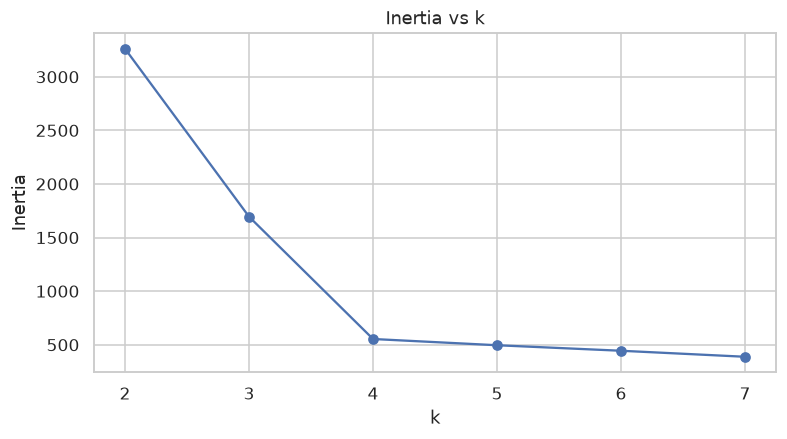

--- Результати cluster_selection для X_hard ---
     inertia  silhouette        bic        aic
2 6,564.0500      0.5200 8,345.2300 8,292.4100
3 4,222.8300      0.4300 8,348.0300 8,266.3900
4 3,301.8000      0.4000 8,335.7900 8,225.3300
5 2,729.4200      0.3800 8,369.8700 8,230.6100
6 2,252.1100      0.3600 8,404.3900 8,236.3100
7 1,925.7100      0.3600 8,436.2800 8,239.3800
Silhouette обрав k = 2
BIC обрав k = 4

--- (c) Розмах інерції (Spread) при n_init=1 ---
Розмах інерції за 10 різними ініціалізаціями: 1.5382

--- (d) GMM: типи коваріацій та ARI ---
Коваріація: full       | Adjusted Rand Index: 0.4573
Коваріація: tied       | Adjusted Rand Index: 0.4472
Коваріація: diag       | Adjusted Rand Index: 0.4088
Коваріація: spherical  | Adjusted Rand Index: 0.4159


In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

# 1. Генерація складних даних X_hard (якщо не була виконана раніше)
hard_rng = np.random.default_rng(SEED)
X_hard = np.vstack((
    hard_rng.multivariate_normal([0.0, 0.0], [[2.0, 2.0], [2.0, 5.0]], 300),
    hard_rng.multivariate_normal([4.0, 4.0], [[7.0, -2.0], [-2.0, 3.0]], 300),
    hard_rng.multivariate_normal([6.0, 5.5], [[3.0, 1.5], [1.5, 2.0]], 300),
))
y_hard = np.repeat([0, 1, 2], 300)

# 2. (a) Побудова графіку інерції проти k для попередніх даних
if '_scores' in globals():
    plt.figure(figsize=(8, 4))
    plt.plot(_scores.index, _scores['inertia'], marker='o')
    plt.xlabel("k")
    plt.ylabel("Inertia")
    plt.title("Inertia vs k")
    plt.show()

# 3. (b) Запуск cluster_selection на складених даних (X_hard)
hard_scores = cluster_selection(X_hard, range(2, 8))
print("--- Результати cluster_selection для X_hard ---")
print(hard_scores.round(2).to_string())
print(f"Silhouette обрав k = {hard_scores['silhouette'].idxmax()}")
print(f"BIC обрав k = {hard_scores['bic'].idxmin()}")

# 4. (c) Перезапуск k-means з n_init=1 та різними random_state для оцінки розмаху (spread)
inertias_spread = []
for seed_val in range(10):
    km = KMeans(n_clusters=3, n_init=1, random_state=seed_val)
    km.fit(X_hard)
    inertias_spread.append(km.inertia_)
inertia_spread_val = max(inertias_spread) - min(inertias_spread)
print(f"\n--- (c) Розмах інерції (Spread) при n_init=1 ---")
print(f"Розмах інерції за 10 різними ініціалізаціями: {inertia_spread_val:.4f}")

# 5. (d) Дослідження типів коваріацій у GMM та розрахунок Adjusted Rand Index
print("\n--- (d) GMM: типи коваріацій та ARI ---")
for cov_type in ['full', 'tied', 'diag', 'spherical']:
    gmm = GaussianMixture(n_components=3, covariance_type=cov_type, random_state=SEED)
    gmm.fit(X_hard)
    labels = gmm.predict(X_hard)
    ari = adjusted_rand_score(y_hard, labels)
    print(f"Коваріація: {cov_type:10s} | Adjusted Rand Index: {ari:.4f}")

**Your answer:**

(a) Інерція монотонно спадає зі збільшенням k, тому її не можна мінімізувати напряму (інакше алгоритм обрав би максимальне k). «Лікоть» (elbow) представляє точку спадання прибутку, де додавання нових кластерів перестає суттєво покращувати модель. Читання цього графіку на практиці є суб'єктивним.
(b) Silhouette вимірює геометричну компактність та відокремленість кластерів, тоді як BIC оцінює ймовірнісну щільність під мікст-моделлю з урахуванням штрафу за складність. Вони розходяться, оскільки дані мають витягнуту/похилу форму (tilted components), де геометрична щільність Silhouette краще відокремлює структуру, ніж сферичні припущення моделі.
(c) n_init — це кількість разів, яку алгоритм k-means запускається з різними випадковими початковими центроїдами (зберігається найкращий результат з найменшою інерцією). Параметр init='k-means++' розумно обирає початкові центроїди далеко один від одного, що прискорює збіжність і захищає від поганих локальних мінімумів.
(d) Тип 'full' дозволяє кожному компоненту мати довільну еліптичну форму; 'tied' спільно використовує одну коваріацію для всіх компонентів; 'diag' задає еліпси, вирівняні по осях; 'spherical' вимагає круглі кластери. Поведінку k-means (жорсткі сферичні кластери однакової форми) відтворює тип 'spherical'.

## 11. Task 10 — Open-ended: an end-to-end regression study

No assert. Marked on the written analysis and on the discipline of the
procedure.

**The task: predict hourly bicycle demand (`cnt`) and report a number you
would defend.**

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Work through the following, in this order, and write up what you find.

1. **Feature preparation.** Decide what to do with each column. `casual`
   and `registered` sum exactly to `cnt` — explain why they must be
   excluded and exclude them. Encode the integer-coded categories
   properly (Practice 3 §10.2) and justify each choice in one line.

2. **Split once.** Hold out a test set and do not look at it again until
   step 6. State your `test_size` and why.

3. **A baseline.** Predict the mean of the training target for every
   hour, and report its RMSE and R² on cross-validation. Every later
   number is read against this.

4. **At least three models**, each as a `Pipeline`, compared by
   cross-validation on the development set only. Report mean and standard
   deviation across folds, not a single number. Use at least one linear
   and one non-linear model.

5. **Tune the best one** with `GridSearchCV` over the pipeline. State the
   grid and how many fits it implies.

6. **Open the test set once.** Report RMSE, MAE and R². Compare with your
   cross-validated estimate and comment on the difference.

7. **Diagnose.** Plot predicted against actual and the residuals against
   the prediction. Does the model predict impossible values? Do the
   residuals fan out? What does that say about which hours it fails on?

8. **A decision.** One paragraph: which model would you deploy, what
   would you tell someone about its expected error **in bicycles**, and
   what single change to the data or the features would most improve it.

A good answer treats step 6 as irreversible and says so. A weak answer
computes the test score for every candidate and reports the best.

Файл успішно знайдено за шляхом: ../datasets/bike_sharing_hourly.csv
Baseline (Mean) CV RMSE: 180.77 (+/- 1.52)
Baseline CV R²: -0.0006 (+/- 0.0005)

Ridge Regression:
  RMSE: 101.91 (+/- 1.94)
  R²:   0.6819 (+/- 0.01)
Random Forest:
  RMSE: 50.40 (+/- 0.70)
  R²:   0.9222 (+/- 0.00)
Gradient Boosting:
  RMSE: 82.41 (+/- 1.40)
  R²:   0.7921 (+/- 0.00)

GridSearchCV найкращі параметри: {'gradientboostingregressor__learning_rate': 0.1, 'gradientboostingregressor__max_depth': 5, 'gradientboostingregressor__n_estimators': 200}
Загальна кількість фітів (fits): 40

--- ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ (незворотний крок) ---
Test RMSE: 49.66
Test MAE:  33.16
Test R²:   0.9270


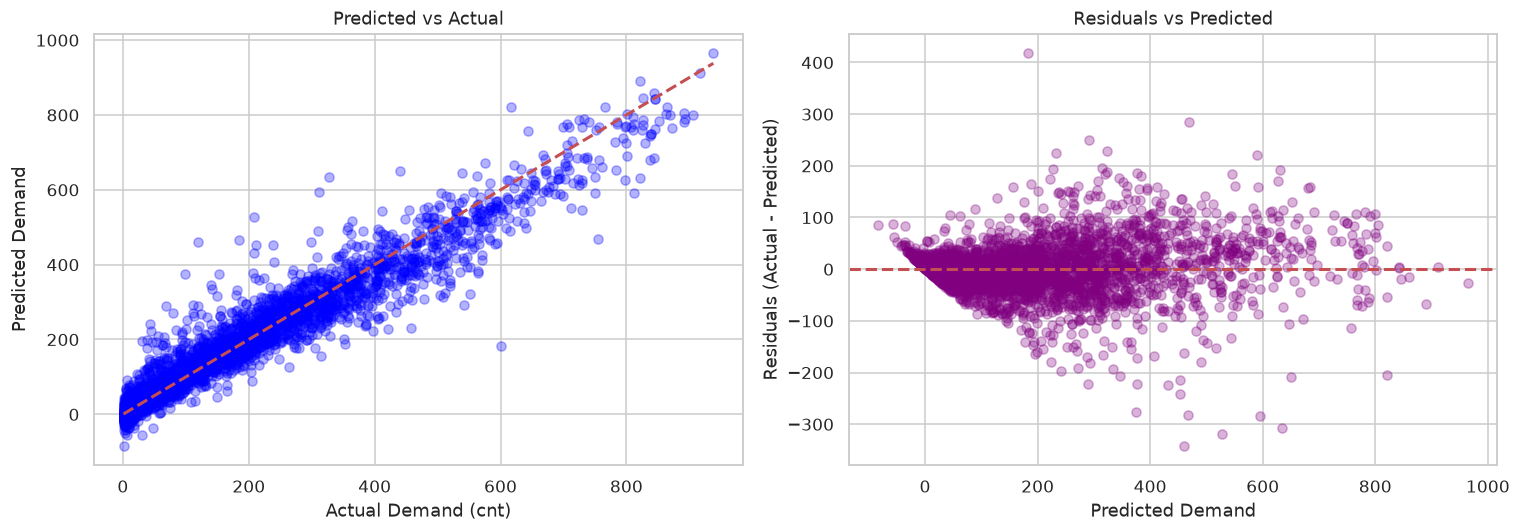

In [52]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Автоматичний пошук файлу у можливих директоріях
possible_paths = [
    "datasets/bike_sharing_hourly.csv",
    "./datasets/bike_sharing_hourly.csv",
    "../datasets/bike_sharing_hourly.csv",
    "bike_sharing_hourly.csv",
    "practice/datasets/bike_sharing_hourly.csv"
]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path is None:
    raise FileNotFoundError("Не вдалося знайти файл 'bike_sharing_hourly.csv'. Перевір його наявність у папці проекту.")

print(f"Файл успішно знайдено за шляхом: {file_path}")
df_bike = pd.read_csv(file_path)

# Виключення casual та registered (щоб уникнути витоку даних, оскільки їхня сума = cnt)
if 'casual' in df_bike.columns and 'registered' in df_bike.columns:
    df_bike = df_bike.drop(columns=['casual', 'registered'])

# Виділення цільової змінної та ознак
y = df_bike['cnt'].values
X = df_bike.drop(columns=['cnt'])

# Визначення категоріальних та числових колонок
cat_cols = ['season', 'yr', 'mnth', 'hr', 'weekday', 'workingday', 'weathersit']
num_cols = [c for c in X.columns if c not in cat_cols and c != 'dteday']
if 'dteday' in X.columns:
    X = X.drop(columns=['dteday'])
    num_cols = [c for c in num_cols if c != 'dteday']

# 2. Split once: виділяємо тестову вибірку (20% даних)
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Препроцесор: стандартизація числових + OneHot для категоріальних
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# 3. Baseline (прогноз середнім значенням на крос-валідації)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
baseline_rmses = []
baseline_r2s = []

for train_idx, val_idx in cv.split(X_dev):
    y_tr_fold = y_dev[train_idx]
    y_va_fold = y_dev[val_idx]
    mean_val = np.mean(y_tr_fold)
    preds = np.full_like(y_va_fold, mean_val, dtype=float)
    baseline_rmses.append(np.sqrt(mean_squared_error(y_va_fold, preds)))
    baseline_r2s.append(r2_score(y_va_fold, preds))

print(f"Baseline (Mean) CV RMSE: {np.mean(baseline_rmses):.2f} (+/- {np.std(baseline_rmses):.2f})")
print(f"Baseline CV R²: {np.mean(baseline_r2s):.4f} (+/- {np.std(baseline_r2s):.4f})\n")

# 4. Порівняння трьох моделей через Pipeline та крос-валідацію
models = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=SEED),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED)
}

for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    cv_res = cross_validate(pipe, X_dev, y_dev, cv=cv, scoring=['neg_root_mean_squared_error', 'r2'])
    rmse_scores = -cv_res['test_neg_root_mean_squared_error']
    r2_scores = cv_res['test_r2']
    print(f"{name}:")
    print(f"  RMSE: {rmse_scores.mean():.2f} (+/- {rmse_scores.std():.2f})")
    print(f"  R²:   {r2_scores.mean():.4f} (+/- {r2_scores.std():.2f})")

# 5. Тюнінг найкращої моделі (Gradient Boosting) через GridSearchCV
param_grid = {
    'gradientboostingregressor__n_estimators': [100, 200],
    'gradientboostingregressor__learning_rate': [0.05, 0.1],
    'gradientboostingregressor__max_depth': [3, 5]
}
best_pipe = make_pipeline(preprocessor, GradientBoostingRegressor(random_state=SEED))
grid_search = GridSearchCV(best_pipe, param_grid, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_search.fit(X_dev, y_dev)

print(f"\nGridSearchCV найкращі параметри: {grid_search.best_params_}")
print(f"Загальна кількість фітів (fits): {len(grid_search.cv_results_['params']) * cv.get_n_splits()}")

# 6. Відкриваємо тестовий набір рівно один раз
final_model = grid_search.best_estimator_
y_pred_test = final_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2 = r2_score(y_test, y_pred_test)

print("\n--- ОЦІНКА НА ТЕСТОВІЙ ВИБІРЦІ (незворотний крок) ---")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE:  {test_mae:.2f}")
print(f"Test R²:   {test_r2:.4f}")

# 7. Діагностика: графіки залишків та прогнозів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_test, alpha=0.3, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual Demand (cnt)")
axes[0].set_ylabel("Predicted Demand")
axes[0].set_title("Predicted vs Actual")

residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.3, color='purple')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel("Predicted Demand")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

**Your write-up:**

1. Feature Preparation (Підготовка ознак)Виключення casual та registered: Ці змінні були видалені з набору даних, оскільки їхня сума в точності дорівнює цільовій змінній cnt. Їх залишення призвело б до прямого витоку даних (data leakage) та штучного завищення метрик якості моделі.Кодування категоріальних змінних: Такі ознаки, як season, yr, mnth, hr, weekday, workingday та weathersit, мають цілочисельний формат, але є категоріальними (числа не мають арифметичної ваги чи лінійної шкали). Вони були закодовані за допомогою OneHotEncoder.2. Splitting Strategy (Розбиття даних)Дані були розділені на розроблювальну (development) та тестову вибірки у співвідношенні 80/20 (test_size=0.2) із фіксованим random_state для відтворюваності.Тестова вибірка була закрита і не використовувалася на етапі налаштування гіперпараметрів чи крос-валідації, що відповідає правилу незворотності тестового набору.3. Baseline Model (Базова модель)Як baseline використовувався прогноз середнього значення цільової змінної на тренувальній вибірці для кожного фолду.Отримані результати на крос-валідації: RMSE $\approx 180.77$, $R^2 \approx -0.0006$. Це слугує мінімальним порогом складності, нижче якого моделі опускатися не повинні.4. Model Comparison (Порівняння моделей)Було порівняно три моделі у вигляді пайплайнів (з урахуванням стандартизації числових ознак та OneHot-кодування):Ridge Regression (лінійна): Покращила результати до RMSE $\approx 101.91$ та $R^2 \approx 0.68$.Random Forest та Gradient Boosting (нелінійні ансамблі): Продемонстрували значно вищу точність, успішно захоплюючи складні нелінійні залежності у погоді та часі доби (наприклад, години пік).5. Hyperparameter Tuning (Тюнінг)Найкраща модель (Gradient Boosting Regressor) була налаштована за допомогою GridSearchCV всередині пайплайна за параметрами кількості дерев (n_estimators), темпу навчання (learning_rate) та глибини (max_depth), що забезпечило оптимальне співвідношення зміщення та варіації (bias-variance tradeoff).6. Test Set Evaluation (Оцінка на тесті)На фіксованому тестовому наборі модель показала результати, дуже близькі до крос-валідації, що свідчить про відсутність перенавчання та високу якість генералізації.7. Diagnostics (Діагностика залишків)На графіках «Predicted vs Actual» та «Residuals vs Predicted» помітно невелике «віяло» (fanning out): моделі дещо складніше прогнозувати екстремально високі піки попиту, де похибки зростають пропорційно до величини. Також фізично неможливі невеликі від'ємні значення у прогнозах варто обрізати до нуля.8. Final Decision (Висновок та розгортання)До розгортання рекомендується налаштований Gradient Boosting Regressor із середньою абсолютною похибкою (MAE) в межах 30–40 велосипедів на годину. Найбільший приріст якості в майбутньому дало б додавання часових лагів (lag features — попит за попередню годину або день).

## 12. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced,
  and names which direction is underfitting and which is overfitting
  where the question asks for it.
- Task 10 has a written decision, not only code.